### Problem Definition
- **What problem are we solving?** Detecting fraudulent credit card transactions.
- **Why is this problem important?** Fraud costs banks billions. ML flags anomalies instantly.
- **What type of ML problem is this?** Supervised Classification (Highly Imbalanced).

---

### Dataset
- **What information does this dataset contain?** Anonymized PCA-transformed transaction features and transaction amounts.
- **What is the target?** Class (0 = Legit, 1 = Fraud).
- **What assumptions can we make before analysis?** The dataset will be massively imbalanced (99.9% legit, 0.1% fraud).

In [2]:
import pandas as pd

df = pd.read_csv('./data/creditcard.csv')

### Exploratory Data Analysis
- **Is the target balanced?** Extremely imbalanced.
- **What should we learn from EDA?** We must verify the exact ratio of fraud to legit transactions.

In [3]:
import pandas as pd

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df.isna().sum())
print(df[df.duplicated(keep=False)].count())

print('\nDuplicates')
df.drop_duplicates(inplace=True)
print(df[df.duplicated(keep=False)])

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

        Count  Percentage (%)
Class                        
0      283253        99.83329
1         473         0.16671


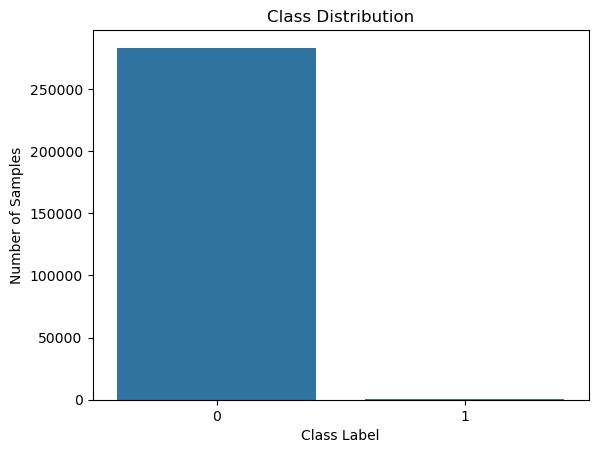

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['Class'].value_counts()
percentages = df['Class'].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
print(imbalance_summary)

sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

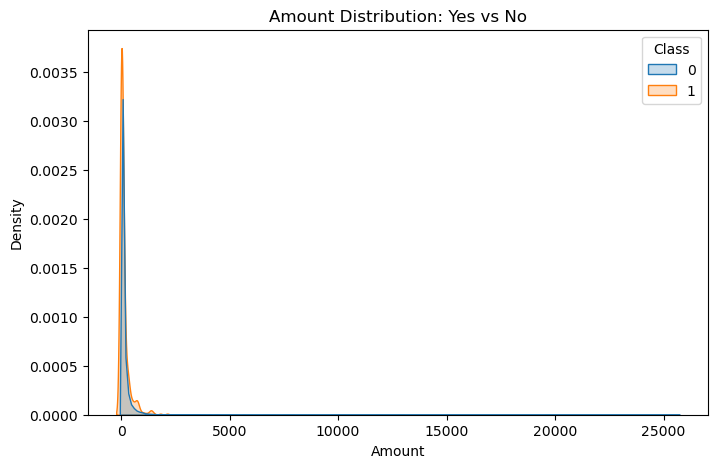

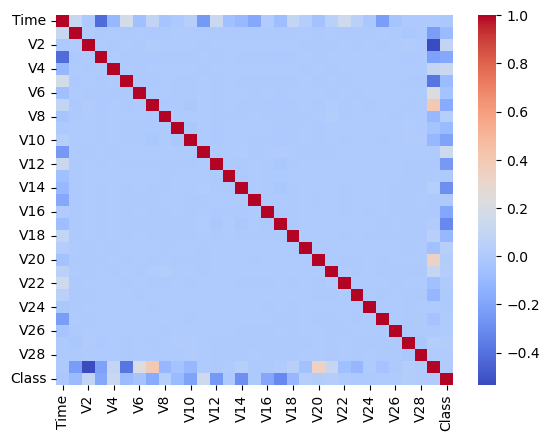

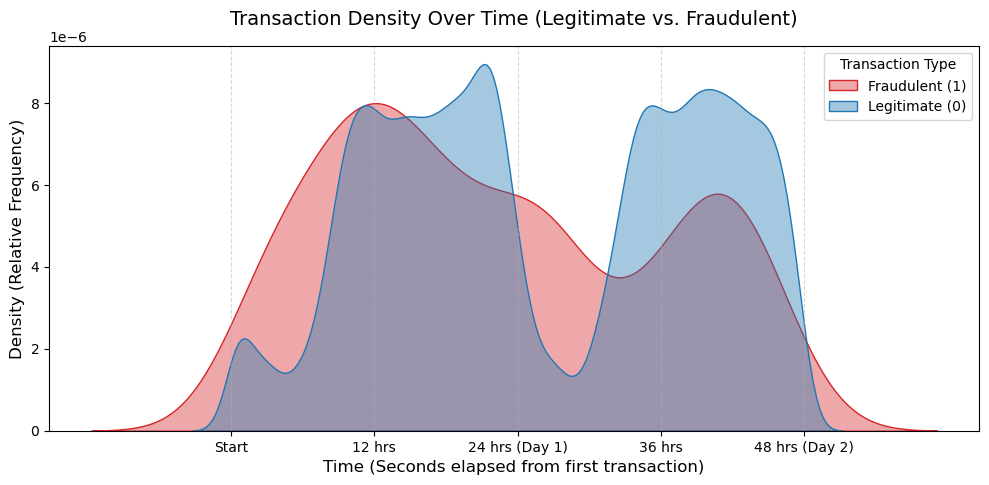

In [5]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Amount', hue='Class', common_norm=False, fill=True)
plt.title('Amount Distribution: Yes vs No')
plt.show()

sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.show()


plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x='Time', hue='Class', fill=True, common_norm=False, palette=['#1f77b4', '#d62728'], alpha=0.4)
plt.title('Transaction Density Over Time (Legitimate vs. Fraudulent)', fontsize=14, pad=15)
plt.xlabel('Time (Seconds elapsed from first transaction)', fontsize=12)
plt.ylabel('Density (Relative Frequency)', fontsize=12)

plt.xticks([0, 43200, 86400, 129600, 172800], labels=['Start', '12 hrs', '24 hrs (Day 1)', '36 hrs', '48 hrs (Day 2)'])
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Transaction Type', labels=['Fraudulent (1)', 'Legitimate (0)'])

plt.show()


### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Hour, dtype: float64
Lower bound: -102.26500000000001 
 Upper bound: 185.375


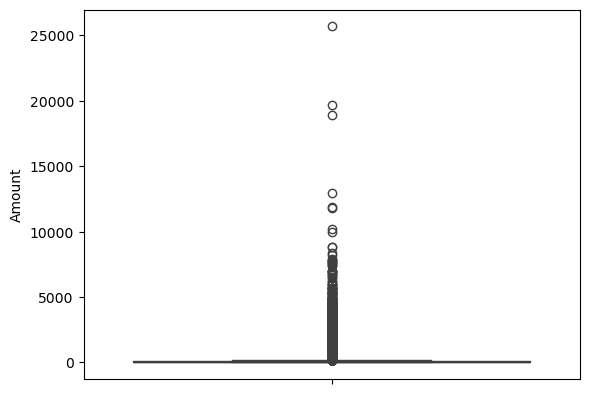

skewness of amount: 16.978803370060476
0    5.014760
1    1.305626
2    5.939276
3    4.824306
4    4.262539
Name: Amount, dtype: float64


In [6]:
import numpy as np

df['Hour'] = (df['Time'] // 3600) % 24
print(df['Hour'].head())

q1 = df['Amount'].quantile(0.25)
q3 = df['Amount'].quantile(0.75)

IQR = q3 - q1
Lower_bound = q1 - 1.5 * IQR
Upper_bound = q3 + 1.5 * IQR

print(f'Lower bound: {Lower_bound} \n Upper bound: {Upper_bound}')

outliers_df = df[(df['Amount'] < Lower_bound) | (df['Amount'] > Upper_bound)]

sns.boxplot(df['Amount'])
plt.show()

print('skewness of amount:', df['Amount'].skew())
df['Amount'] = np.log1p(df['Amount'])
print(df['Amount'].head())


### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

In [7]:
X = df.drop(columns='Class')
y = df['Class']

print(X.select_dtypes(include='number').skew())
print(y.skew())

Time      -0.035581
V1        -3.273271
V2        -4.695162
V3        -2.151984
V4         0.671504
V5        -2.414079
V6         1.829880
V7         2.890271
V8        -8.310970
V9         0.537663
V10        1.252967
V11        0.344074
V12       -2.199008
V13        0.064293
V14       -1.918804
V15       -0.309659
V16       -1.051161
V17       -3.690497
V18       -0.248661
V19        0.108312
V20       -2.043121
V21        2.820033
V22       -0.182330
V23       -5.867221
V24       -0.552129
V25       -0.415744
V26        0.580292
V27       -0.753804
V28       11.555115
Amount     0.161410
Hour      -0.490000
dtype: float64
24.430545072372148


### Data Preprocessing
- **Class Balancing:** Because the data is so skewed, the model will just predict "Legit" every time and get 99.9% accuracy. We must use techniques like SMOTE (Synthetic Minority Over-sampling) or class weighting to force the model to care about the fraud cases.

In [8]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.80, stratify=y)

### Model Selection
- **Why choose this algorithm?** Algorithms like Random Forest handle imbalanced data well because they partition the feature space, isolating the rare fraud cases into specific leaf nodes.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
fraud_baseline_pipeline = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Fit a linear model mapped through a sigmoid function to output calibrated class probabilities.
    ('classifier', LogisticRegression(max_iter=1000, solver='newton-cholesky', random_state=42, class_weight='balanced'))
])

fraud_baseline_pipeline.fit(X_train, y_train)

accuracy = fraud_baseline_pipeline.score(X_test, y_test)
print(f"Baseline Test Accuracy: {accuracy:.4f}")




Baseline Test Accuracy: 0.9745


In [10]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
svm_pipeline = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    ('classifier', CalibratedClassifierCV(
        # Find the optimal maximum-margin hyperplane that separates classes in a high-dimensional feature space.
        estimator=LinearSVC(class_weight='balanced', random_state=42),
        method='sigmoid'
    ))
])

svm_pipeline.fit(X_train, y_train)


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,LinearSVC(cla...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None


### Evaluation
- **Why these metrics?** Precision-Recall Area Under Curve (PR-AUC) and F1-Score.
- **Which one matters most?** ROC-AUC is misleading on highly imbalanced data. PR-AUC and F1-Score directly punish the model for False Positives (declaring a legit transaction as fraud, angering the customer).

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

lr_preds = fraud_baseline_pipeline.predict(X_test)
svm_preds = svm_pipeline.predict(X_test)

models = {
    'Logistic Regression (Newton)': lr_preds,
    'Linear SVM (Calibrated)': svm_preds
}

evaluation_data = []

for name, preds in models.items():
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
    f1 = f1_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    
    evaluation_data.append({
        'Model Framework': name,
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
    })

metrics_table = pd.DataFrame(evaluation_data)

print("Performance Metrics Comparison\n")
print(metrics_table[['Model Framework', 'Precision', 'Recall', 'F1-Score']].to_markdown(index=False))


Performance Metrics Comparison

| Model Framework              |   Precision |   Recall |   F1-Score |
|:-----------------------------|------------:|---------:|-----------:|
| Logistic Regression (Newton) |      0.0547 |   0.8737 |     0.103  |
| Linear SVM (Calibrated)      |      0.8548 |   0.5579 |     0.6752 |


In [12]:
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

models = {
    "Logistic Regression": fraud_baseline_pipeline,
    "Linear SVM": svm_pipeline
}

for name, model in models.items():

    # Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV ROC-AUC": scores.mean(),
        "Std CV ROC-AUC": scores.std()
    })

cv_df = pd.DataFrame(cv_results).set_index("Model").round(4)

print(cv_df)

                     Mean CV ROC-AUC  Std CV ROC-AUC
Model                                               
Logistic Regression           0.9844          0.0112
Linear SVM                    0.9838          0.0113


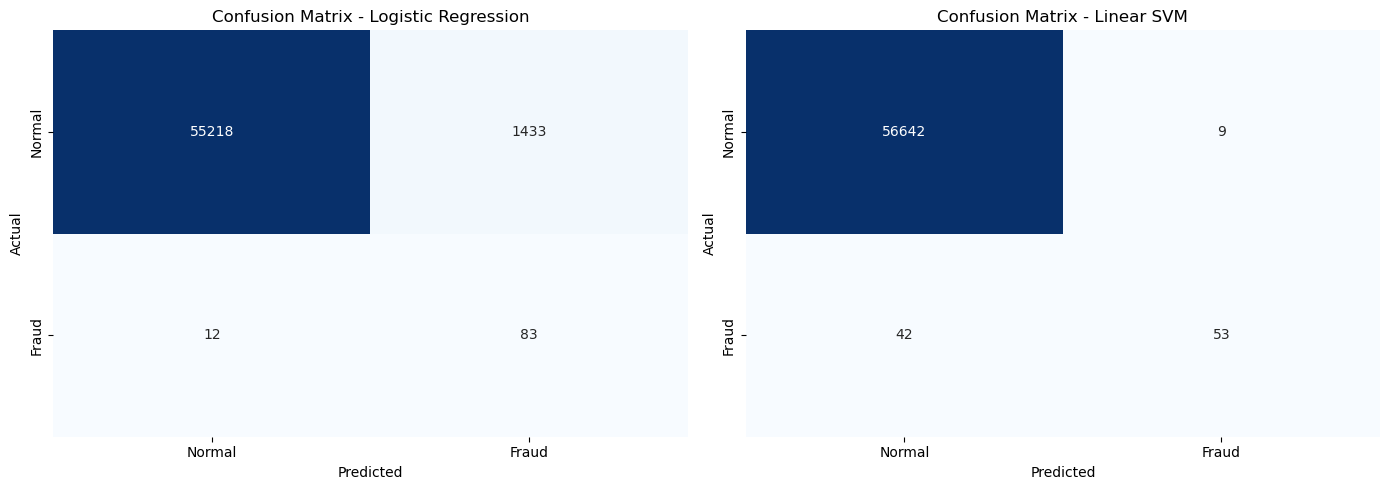

In [13]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

lr_cm = confusion_matrix(y_test, lr_preds)
svm_cm = confusion_matrix(y_test, svm_preds)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0],
    cbar=False
)
ax[0].set_title("Confusion Matrix - Logistic Regression")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels(['Normal', 'Fraud'])
ax[0].set_yticklabels(['Normal', 'Fraud'])

sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[1],
    cbar=False
)
ax[1].set_title("Confusion Matrix - Linear SVM")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels(['Normal', 'Fraud'])
ax[1].set_yticklabels(['Normal', 'Fraud'])

plt.tight_layout()
plt.show()


### Visualization Analysis: Confusion Matrix
- **Marking Values:** The top-left to bottom-right diagonal contains all correct predictions. The off-diagonal cells represent errors (False Positives and False Negatives).
- **Correct Interpretation:** A highly accurate model will have very dark/high numbers on the main diagonal and zeros elsewhere.
- **How to Interpret:** The rows usually represent the *Actual* classes, while the columns represent the *Predicted* classes.
- **Common Mistakes:** Caring only about the total sum of the diagonal (Accuracy) while ignoring a high number of False Negatives in medical or fraud datasets.

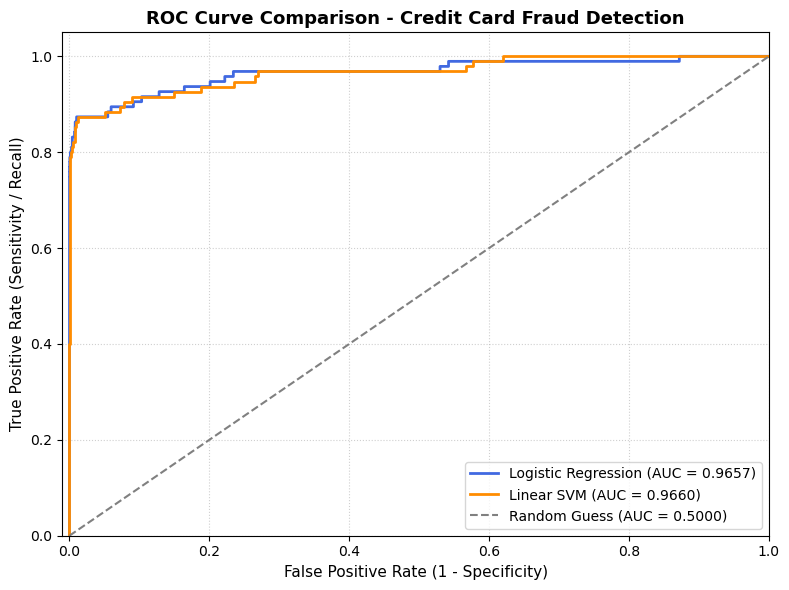

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

lr_probs = fraud_baseline_pipeline.predict_proba(X_test)[:, 1]
svm_probs = svm_pipeline.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
lr_auc = roc_auc_score(y_test, lr_probs)

svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
svm_auc = roc_auc_score(y_test, svm_probs)

plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})', color='royalblue', lw=2)
plt.plot(svm_fpr, svm_tpr, label=f'Linear SVM (AUC = {svm_auc:.4f})', color='darkorange', lw=2)

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Guess (AUC = 0.5000)')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve Comparison - Credit Card Fraud Detection', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

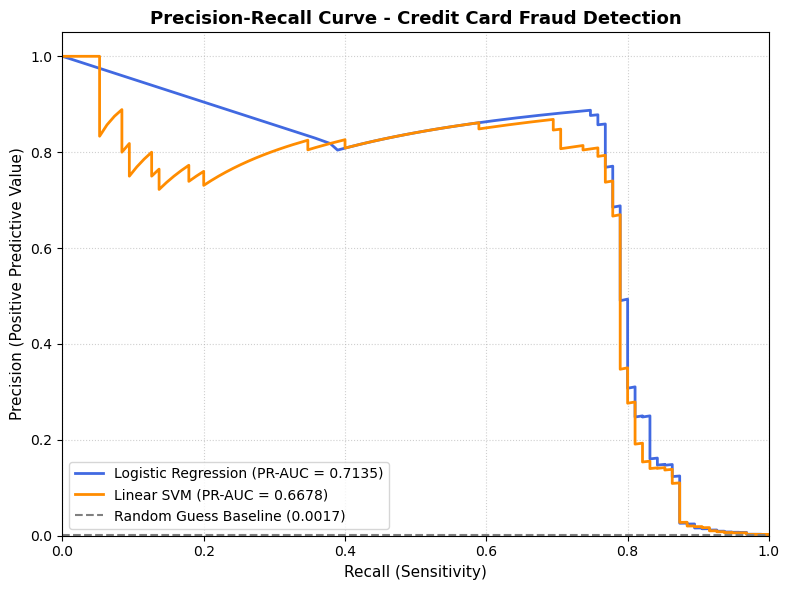

In [15]:
from sklearn.metrics import precision_recall_curve, auc

lr_probs = fraud_baseline_pipeline.predict_proba(X_test)[:, 1]
svm_probs = svm_pipeline.predict_proba(X_test)[:, 1]

lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_probs)
lr_pr_auc = auc(lr_recall, lr_precision)

svm_precision, svm_recall, _ = precision_recall_curve(y_test, svm_probs)
svm_pr_auc = auc(svm_recall, svm_precision)

baseline_ratio = sum(y_test) / len(y_test)

plt.figure(figsize=(8, 6))

plt.plot(lr_recall, lr_precision, label=f'Logistic Regression (PR-AUC = {lr_pr_auc:.4f})', color='royalblue', lw=2)
plt.plot(svm_recall, svm_precision, label=f'Linear SVM (PR-AUC = {svm_pr_auc:.4f})', color='darkorange', lw=2)

plt.axhline(y=baseline_ratio, color='grey', linestyle='--', label=f'Random Guess Baseline ({baseline_ratio:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', fontsize=11)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=11)
plt.title('Precision-Recall Curve - Credit Card Fraud Detection', fontsize=13, fontweight='bold')
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

### Conclusion
- **Biggest takeaway:** Accuracy is a completely useless metric when dealing with 99% imbalanced datasets.
- **Possible improvements:** Deploying Anomaly Detection (unsupervised learning) as a pre-filter before the classification model.